In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/fer2013.tar.gz
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/example_submission.csv
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/train.csv
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/test.csv


In [3]:
!pip install wandb -q

import os, sys, math, random, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models as tv_models
import wandb


SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("WARNING: No GPU")

CSV_PATH      = "/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv"
SAVE_DIR      = pathlib.Path("/kaggle/working/checkpoints")
SAVE_DIR.mkdir(exist_ok=True)
ENTITY        = "akave23-free-university-of-tbilisi-"
WANDB_PROJECT = "Facial-Expression-Recognition-Challenge"
EMOTIONS      = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [4]:
os.environ["WANDB_API_KEY"] = "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"
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: akave23 (akave23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row    = self.data.iloc[idx]
        pixels = np.array(row["pixels"].split(), dtype=np.uint8).reshape(48, 48)
        image  = Image.fromarray(pixels, mode="L")
        label  = int(row["emotion"])
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        return image, label


def get_transforms(augment=True):
    norm = transforms.Normalize(mean=[0.5], std=[0.5])
    if augment:
        train_tf = transforms.Compose([
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomRotation(10),
            transforms.RandomCrop(48, padding=4),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(), norm,
        ])
    else:
        train_tf = transforms.Compose([transforms.ToTensor(), norm])
    val_tf = transforms.Compose([transforms.ToTensor(), norm])
    return train_tf, val_tf


def load_data(batch_size=64, augment=True):
    df = pd.read_csv(CSV_PATH)
    df.columns = [c.strip() for c in df.columns]
    train_df = df[df["Usage"] == "Training"]
    val_df   = df[df["Usage"] == "PublicTest"]
    test_df  = df[df["Usage"] == "PrivateTest"]
    print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
    train_tf, val_tf = get_transforms(augment)
    pin = DEVICE.type == "cuda"
    tr = DataLoader(FERDataset(train_df, train_tf), batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=pin)
    vl = DataLoader(FERDataset(val_df,   val_tf),   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=pin)
    ts = DataLoader(FERDataset(test_df,  val_tf),   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=pin)
    return tr, vl, ts

Dataset shape: (35887, 3)

Usage split:
 Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64

Emotion counts:
 emotion
Angry       4953
Disgust      547
Fear        5121
Happy       8989
Sad         6077
Surprise    4002
Neutral     6198
Name: count, dtype: int64


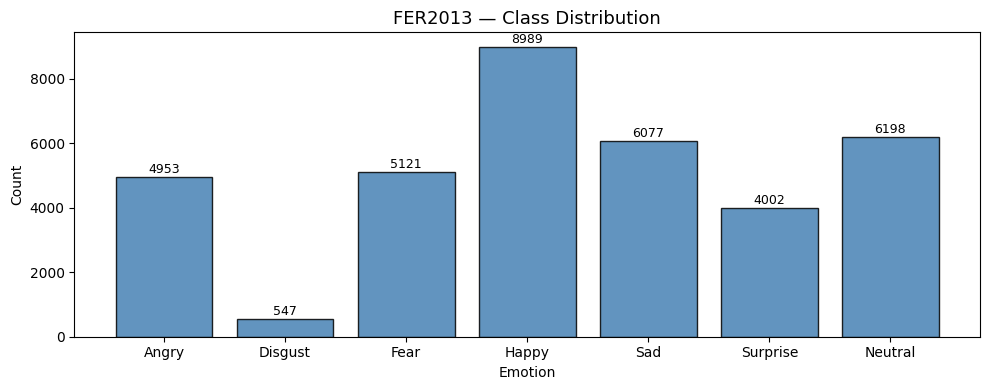


Note: 'Disgust' is heavily underrepresented — model will struggle with this class.


/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


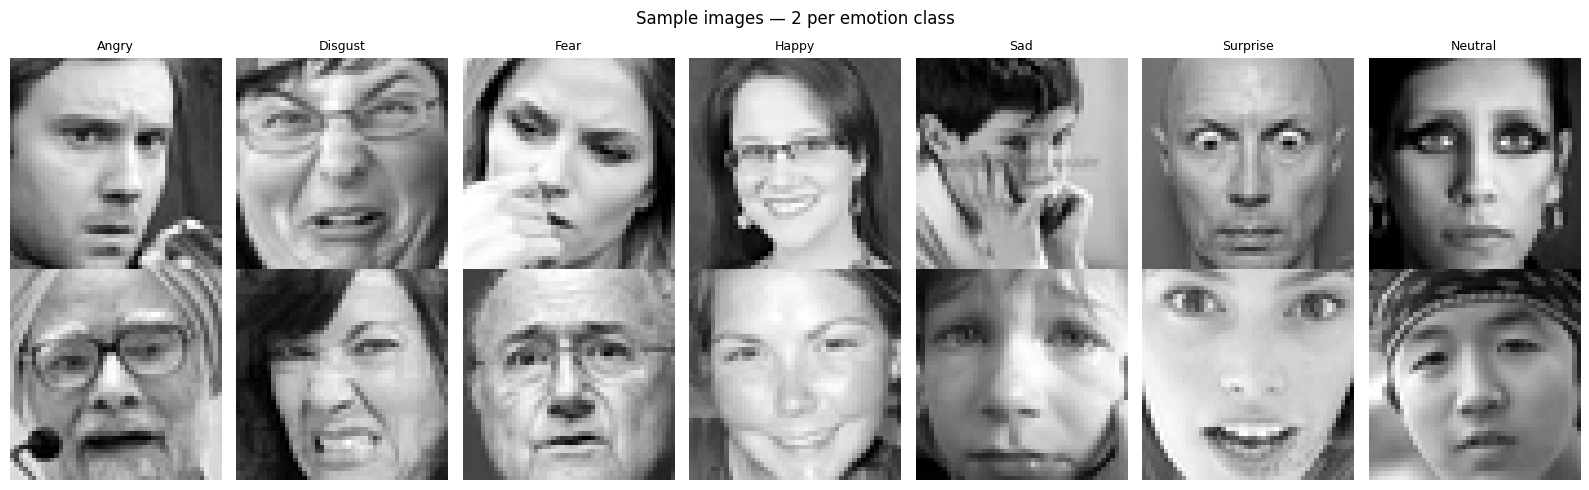

In [6]:
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]
print("Dataset shape:", df.shape)
print("\nUsage split:\n", df["Usage"].value_counts())
print("\nEmotion counts:\n", df["emotion"].value_counts().sort_index()
      .rename(index={i: EMOTIONS[i] for i in range(7)}))

# Class distribution chart
counts = df["emotion"].value_counts().sort_index()
plt.figure(figsize=(10, 4))
bars = plt.bar(EMOTIONS, counts.values, color="steelblue", edgecolor="black", alpha=0.85)
for bar, v in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+30,
             str(v), ha="center", va="bottom", fontsize=9)
plt.title("FER2013 — Class Distribution", fontsize=13)
plt.xlabel("Emotion"); plt.ylabel("Count")
plt.tight_layout(); plt.show()
print("\nNote: 'Disgust' is heavily underrepresented — model will struggle with this class.")

# Sample images
_, val_tf = get_transforms(False)
sample_df = df[df["Usage"] == "Training"].reset_index(drop=True)
sample_ds = FERDataset(sample_df, val_tf)
fig, axes = plt.subplots(2, 7, figsize=(16, 5))
shown = {i: [] for i in range(7)}
for i in range(len(sample_ds)):
    img, lbl = sample_ds[i]
    if len(shown[lbl]) < 2:
        shown[lbl].append(img.squeeze().numpy() * 0.5 + 0.5)
    if all(len(v) == 2 for v in shown.values()):
        break
for row in range(2):
    for col in range(7):
        axes[row, col].imshow(shown[col][row], cmap="gray")
        if row == 0: axes[row, col].set_title(EMOTIONS[col], fontsize=9)
        axes[row, col].axis("off")
plt.suptitle("Sample images — 2 per emotion class", fontsize=12)
plt.tight_layout(); plt.show()

 **Model Architectures**

In [7]:
# ── Architecture 1: TinyNet ──────────────────────────────────────────────────
class TinyNet(nn.Module):
    """
    Only 2 conv layers with 8 and 16 filters.
    Deliberately too small — will demonstrate UNDERFITTING.
    Expected: train ~35-42%, val ~35-40% (both low, small gap).
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc    = nn.Linear(16*12*12, 7)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        return self.fc(x.view(x.size(0), -1))


# ── Architecture 2: SmallCNN ─────────────────────────────────────────────────
class SmallCNN(nn.Module):
    """
    3 conv blocks with BatchNorm.
    dropout=0.0 → will OVERFIT (train >> val).
    dropout=0.4 → regularisation reduces the gap.
    """
    def __init__(self, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2,2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(128*6*6, 512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, 7),
        )

    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1))


# ── Architecture 3: MediumCNN ────────────────────────────────────────────────
class MediumCNN(nn.Module):
    """
    4 conv blocks, double-conv per block, BatchNorm, spatial Dropout.
    Balanced model with augmentation — expected train ≈ val accuracy.
    """
    def __init__(self, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.1),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.2),

            nn.Conv2d(128,256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(256*3*3, 512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, 256),     nn.ReLU(inplace=True),
            nn.Linear(256, 7),
        )

    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1))


# ── Architecture 4: DeepCNN ──────────────────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(c,c,3,padding=1,bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True),
            nn.Conv2d(c,c,3,padding=1,bias=False), nn.BatchNorm2d(c),
        )
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(x + self.block(x))

class DeepCNN(nn.Module):
    """
    Residual skip connections + Global Average Pooling.
    Skip connections solve vanishing gradients in deeper networks.
    Expected: best pure-CNN result.
    """
    def __init__(self, dropout=0.5):
        super().__init__()
        self.stem   = nn.Sequential(nn.Conv2d(1,64,3,padding=1,bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.stage1 = nn.Sequential(ResidualBlock(64), nn.MaxPool2d(2,2))
        self.stage2 = nn.Sequential(nn.Conv2d(64,128,3,padding=1,bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
                                    ResidualBlock(128), nn.MaxPool2d(2,2))
        self.stage3 = nn.Sequential(nn.Conv2d(128,256,3,padding=1,bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
                                    ResidualBlock(256), nn.MaxPool2d(2,2))
        self.stage4 = nn.Sequential(nn.Conv2d(256,512,3,padding=1,bias=False), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
                                    nn.MaxPool2d(2,2))
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.cls = nn.Sequential(
            nn.Dropout(dropout),   nn.Linear(512,256), nn.ReLU(inplace=True),
            nn.Dropout(dropout/2), nn.Linear(256,7),
        )

    def forward(self, x):
        x = self.stage4(self.stage3(self.stage2(self.stage1(self.stem(x)))))
        return self.cls(self.gap(x).view(x.size(0), -1))


# ── Architecture 5: FERResNet ────────────────────────────────────────────────
class FERResNet(nn.Module):
    """
    Pretrained ResNet18 adapted for 1-channel grayscale + 7 classes.
    freeze_backbone=True  → feature extraction (only head trained).
    freeze_backbone=False → full fine-tune (best expected result).
    """
    def __init__(self, pretrained=True, freeze_backbone=False):
        super().__init__()
        weights = tv_models.ResNet18_Weights.DEFAULT if pretrained else None
        self.backbone = tv_models.resnet18(weights=weights)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if freeze_backbone:
            for name, p in self.backbone.named_parameters():
                if "fc" not in name and "conv1" not in name:
                    p.requires_grad = False
        nf = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(nf,256), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(256,7),
        )

    def forward(self, x):
        return self.backbone(x)


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"{'Model':<22} {'Trainable Params':>18}")
print("─" * 42)
for n, m in [("TinyNet", TinyNet()), ("SmallCNN(d=0)", SmallCNN(0.0)),
             ("SmallCNN(d=0.4)", SmallCNN(0.4)), ("MediumCNN", MediumCNN()),
             ("DeepCNN", DeepCNN()), ("FERResNet", FERResNet(pretrained=False))]:
    print(f"  {n:<20} {count_params(m):>18,}")

Model                    Trainable Params
──────────────────────────────────────────
  TinyNet                          17,383
  SmallCNN(d=0)                 2,456,519
  SmallCNN(d=0.4)               2,456,519
  MediumCNN                     1,896,295
  DeepCNN                       3,233,991
  FERResNet                    11,303,367


**Sanity Checks**

In [8]:
print("=" * 60)
print("SANITY CHECKS — run before any training")
print("=" * 60)

# 1. Forward pass
print("\n── 1. Forward pass (initial loss should be ≈ ln(7) = 1.946) ──")
for name, model in [("TinyNet", TinyNet()), ("SmallCNN", SmallCNN()),
                    ("MediumCNN", MediumCNN()), ("DeepCNN", DeepCNN()),
                    ("FERResNet", FERResNet(pretrained=False))]:
    model.eval().to(DEVICE)
    with torch.no_grad():
        out = model(torch.randn(8,1,48,48).to(DEVICE))
    assert out.shape == (8,7), f"Wrong shape: {out.shape}"
    loss  = nn.CrossEntropyLoss()(out, torch.randint(0,7,(8,)).to(DEVICE)).item()
    ratio = loss / math.log(7)
    ok    = "✓" if 0.5 < ratio < 3.0 else "⚠"
    print(f"  [{name:<18}] {ok}  loss={loss:.4f}  ratio={ratio:.2f}x expected")

# 2. Backward pass
print("\n── 2. Backward pass (all params must receive gradients) ──")
for name, model in [("TinyNet", TinyNet()), ("SmallCNN", SmallCNN()),
                    ("MediumCNN", MediumCNN()), ("DeepCNN", DeepCNN()),
                    ("FERResNet", FERResNet(pretrained=False))]:
    model.train().to(DEVICE)
    opt = torch.optim.Adam(model.parameters())
    opt.zero_grad()
    nn.CrossEntropyLoss()(
        model(torch.randn(8,1,48,48).to(DEVICE)),
        torch.randint(0,7,(8,)).to(DEVICE)
    ).backward()
    dead = [n for n,p in model.named_parameters()
            if p.requires_grad and (p.grad is None or p.grad.abs().sum()==0)]
    print(f"  [{name:<18}] {'✓ all gradients OK' if not dead else '✗ dead: '+str(dead[:2])}")

# 3. Overfit on 1 batch
print("\n── 3. Overfit-on-1-batch test (should reach ~100% in 100 steps) ──")
_tr, _, _ = load_data(batch_size=32, augment=False)
_model = TinyNet().to(DEVICE)
_imgs, _lbls = next(iter(_tr))
_imgs, _lbls = _imgs.to(DEVICE), _lbls.to(DEVICE)
_opt = torch.optim.Adam(_model.parameters(), lr=1e-3)
for step in range(1, 101):
    _opt.zero_grad()
    _out  = _model(_imgs)
    _loss = nn.CrossEntropyLoss()(_out, _lbls)
    _loss.backward(); _opt.step()
    if step % 20 == 0:
        _acc = _out.argmax(1).eq(_lbls).float().mean().item()*100
        print(f"  step {step:3d}: loss={_loss.item():.4f}  acc={_acc:.1f}%")
_final = _out.argmax(1).eq(_lbls).float().mean().item()*100
print(f"  Final: {_final:.1f}%  {'✓ implementation correct' if _final > 90 else '✗ check implementation'}")
print("\n" + "="*60)

SANITY CHECKS — run before any training

── 1. Forward pass (initial loss should be ≈ ln(7) = 1.946) ──
  [TinyNet           ] ✓  loss=1.8193  ratio=0.93x expected
  [SmallCNN          ] ✓  loss=1.9617  ratio=1.01x expected
  [MediumCNN         ] ✓  loss=1.9650  ratio=1.01x expected
  [DeepCNN           ] ✓  loss=1.9415  ratio=1.00x expected
  [FERResNet         ] ✓  loss=2.1331  ratio=1.10x expected

── 2. Backward pass (all params must receive gradients) ──
  [TinyNet           ] ✓ all gradients OK
  [SmallCNN          ] ✓ all gradients OK
  [MediumCNN         ] ✓ all gradients OK
  [DeepCNN           ] ✓ all gradients OK
  [FERResNet         ] ✓ all gradients OK

── 3. Overfit-on-1-batch test (should reach ~100% in 100 steps) ──
Train: 28,709 | Val: 3,589 | Test: 3,589


/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


  step  20: loss=0.4202  acc=93.8%
  step  40: loss=0.0125  acc=100.0%
  step  60: loss=0.0023  acc=100.0%
  step  80: loss=0.0013  acc=100.0%
  step 100: loss=0.0010  acc=100.0%
  Final: 100.0%  ✓ implementation correct



**Training Loop**

In [10]:
def train_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in tqdm(loader, leave=False, desc="train"):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        total      += lbls.size(0)
        correct    += out.argmax(1).eq(lbls).sum().item()
    if scheduler and not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step()
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        out = model(imgs)
        total_loss += criterion(out, lbls).item() * imgs.size(0)
        correct    += out.argmax(1).eq(lbls).sum().item()
        total      += lbls.size(0)
    return total_loss / total, 100.0 * correct / total


def run_experiment(model, tr, vl, ts, cfg, name):
    print(f"\n{'─'*60}\nStarting: {name}\nParams: {count_params(model):,}\n{'─'*60}")
    save = str(SAVE_DIR / f"best_{name}.pth")

    run = wandb.init(
        entity=ENTITY,
        project=WANDB_PROJECT,
        name=name,
        config=cfg,
        reinit=True,
    )
    wandb.watch(model, log="gradients", log_freq=200)

    model = model.to(DEVICE)
    crit  = nn.CrossEntropyLoss()
    lr, wd = cfg["lr"], cfg.get("weight_decay", 0)

    if   cfg["optimizer"] == "adam":  opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif cfg["optimizer"] == "sgd":   opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd, nesterov=True)
    elif cfg["optimizer"] == "adamw": opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    s = cfg.get("scheduler")
    if   s == "cosine":  sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])
    elif s == "plateau": sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    else:                sched = None

    best_val = 0.0
    for epoch in range(cfg["epochs"]):
        tl, ta = train_epoch(model, tr, opt, crit, sched)
        vl_, va = eval_epoch(model, vl, crit)

        if isinstance(sched, torch.optim.lr_scheduler.ReduceLROnPlateau):
            sched.step(vl_)

        wandb.log({
            "epoch":          epoch + 1,
            "train/loss":     tl,
            "train/accuracy": ta,
            "val/loss":       vl_,
            "val/accuracy":   va,
            "learning_rate":  opt.param_groups[0]["lr"],
        })

        if va > best_val:
            best_val = va
            torch.save(model.state_dict(), save)

        print(f"[{epoch+1:03d}/{cfg['epochs']}] "
              f"Train Loss={tl:.4f} Acc={ta:.2f}% | "
              f"Val Loss={vl_:.4f} Acc={va:.2f}%")

    model.load_state_dict(torch.load(save, map_location=DEVICE))
    _, test_acc = eval_epoch(model, ts, crit)

    wandb.log({"test/accuracy": test_acc, "best_val_accuracy": best_val})
    wandb.summary.update({"best_val_accuracy": best_val, "test_accuracy": test_acc})

    print(f"\n✓ {name}  |  Best Val: {best_val:.2f}%  |  Test: {test_acc:.2f}%")
    run.finish()
    return best_val, test_acc

**Load Data**

In [11]:
print("Loading data loaders...")
tr64,  vl64,  ts64  = load_data(batch_size=64, augment=True)
tr64n, vl64n, ts64n = load_data(batch_size=64, augment=False)
tr32,  vl32,  ts32  = load_data(batch_size=32, augment=True)
print("Done.")

Loading data loaders...
Train: 28,709 | Val: 3,589 | Test: 3,589
Train: 28,709 | Val: 3,589 | Test: 3,589
Train: 28,709 | Val: 3,589 | Test: 3,589
Done.


In [18]:
# HYPOTHESIS: 2 conv layers cannot learn facial expressions.
# EXPECTED: both train and val accuracy ~35-42% (underfitting — both low, small gap)
val1, test1 = run_experiment(
    TinyNet(), tr64n, vl64n, ts64n,
    dict(architecture="TinyNet", epochs=30, lr=0.001, batch_size=64,
         optimizer="adam", weight_decay=0, augment=False, scheduler=None,
         notes="Underfitting baseline"),
    "exp1_tinynet_baseline"
)


────────────────────────────────────────────────────────────
Starting: exp1_tinynet_baseline
Params: 17,383
────────────────────────────────────────────────────────────


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[001/30] Train Loss=1.6504 Acc=35.12% | Val Loss=1.5343 Acc=41.18%


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


...

train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[030/30] Train Loss=1.0197 Acc=62.44% | Val Loss=1.4933 Acc=48.82%


/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")



✓ exp1_tinynet_baseline  |  Best Val: 50.63%  |  Test: 49.60%


best_val_accuracy,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁
train/accuracy,▁▃▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇███████████
train/loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▅▅▆▆▇▆▆▇▇▇▇▇▇▇▇███▇▇▇█▇█▇▇▇▇
val/loss,█▅▃▂▂▁▁▂▂▁▂▂▂▃▂▂▃▃▃▃▃▄▄▄▆▅▅▅▆▆
best_val_accuracy,50.62692
epoch,30
learning_rate,0.001


In [19]:
# HYPOTHESIS: 3 conv blocks have capacity but no regularisation → memorises training set.
# EXPECTED: train ~75-85%, val ~55-60% (large gap = overfitting)
val2, test2 = run_experiment(
    SmallCNN(dropout=0.0), tr64n, vl64n, ts64n,
    dict(architecture="SmallCNN", dropout=0.0, epochs=50, lr=0.001, batch_size=64,
         optimizer="adam", weight_decay=0, augment=False, scheduler=None,
         notes="Overfitting demo — no dropout, no augmentation"),
    "exp2_smallcnn_no_dropout"
)


────────────────────────────────────────────────────────────
Starting: exp2_smallcnn_no_dropout
Params: 2,456,519
────────────────────────────────────────────────────────────


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[001/50] Train Loss=1.6147 Acc=39.14% | Val Loss=1.3270 Acc=49.60%


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[002/50] Train Loss=1.2573 Acc=52.06% | Val Loss=1.2431 Acc=52.08%


...

train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[050/50] Train Loss=0.0423 Acc=98.77% | Val Loss=4.0768 Acc=58.18%


/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")



✓ exp2_smallcnn_no_dropout  |  Best Val: 60.24%  |  Test: 60.32%


best_val_accuracy,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁
train/accuracy,▁▃▃▄▄▅▅▆▆▇▇▇████████████████████████████
train/loss,█▆▆▅▅▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▆▅▇▇██▇▇▇█▇▇▇▆▆▆▇▇▇▇▇▇▇▆▆▇▇▇▇▇▇▆▇█▇▇▇▇
val/loss,▁▁▁▁▁▁▁▂▂▂▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇███
best_val_accuracy,60.23962
epoch,50
learning_rate,0.001


In [20]:
# HYPOTHESIS: Adding Dropout(0.4) + augmentation directly fixes overfitting from Exp 2.
# EXPECTED: train-val gap shrinks significantly
val3, test3 = run_experiment(
    SmallCNN(dropout=0.4), tr64, vl64, ts64,
    dict(architecture="SmallCNN", dropout=0.4, epochs=50, lr=0.001, batch_size=64,
         optimizer="adam", weight_decay=1e-4, augment=True, scheduler="cosine",
         notes="Dropout + augmentation fix overfitting"),
    "exp3_smallcnn_regularised"
)


────────────────────────────────────────────────────────────
Starting: exp3_smallcnn_regularised
Params: 2,456,519
────────────────────────────────────────────────────────────


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[001/50] Train Loss=1.8058 Acc=26.47% | Val Loss=1.6099 Acc=39.01%


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[002/50] Train Loss=1.6037 Acc=35.97% | Val Loss=1.4164 Acc=44.97%


...

train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[050/50] Train Loss=0.9728 Acc=63.69% | Val Loss=0.9568 Acc=63.78%


/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")



✓ exp3_smallcnn_regularised  |  Best Val: 64.17%  |  Test: 65.37%


best_val_accuracy,▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
learning_rate,███████▇▇▇▇▇▆▆▆▅▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
test/accuracy,▁
train/accuracy,▁▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train/loss,█▆▆▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▃▄▄▅▅▅▅▆▆▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇▇█▇███████████
val/loss,█▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,64.16829
epoch,50
learning_rate,0


In [21]:
# HYPOTHESIS: 4 deeper blocks + double-conv + BatchNorm improves accuracy further.
# EXPECTED: best accuracy so far, good generalisation
val4, test4 = run_experiment(
    MediumCNN(dropout=0.4), tr64, vl64, ts64,
    dict(architecture="MediumCNN", dropout=0.4, epochs=60, lr=0.001, batch_size=64,
         optimizer="adam", weight_decay=1e-4, augment=True, scheduler="cosine",
         notes="4 conv blocks + Adam"),
    "exp4_mediumcnn_adam"
)


────────────────────────────────────────────────────────────
Starting: exp4_mediumcnn_adam
Params: 1,896,295
────────────────────────────────────────────────────────────


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[001/60] Train Loss=1.7713 Acc=26.58% | Val Loss=1.6201 Acc=35.55%


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[002/60] Train Loss=1.5469 Acc=38.63% | Val Loss=1.4816 Acc=42.27%


...

train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[060/60] Train Loss=0.8054 Acc=70.18% | Val Loss=0.8992 Acc=66.40%


/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")



✓ exp4_mediumcnn_adam  |  Best Val: 66.51%  |  Test: 69.41%


best_val_accuracy,▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇████
learning_rate,██████▇▇▇▇▇▇▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
test/accuracy,▁
train/accuracy,▁▃▄▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train/loss,█▇▇▆▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▄▅▅▆▆▆▆▆▇▇▆▇▇▇▇▇▇▇▇███████████████████
val/loss,█▇▅▄▄▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,66.50878
epoch,60
learning_rate,0


In [22]:
# HYPOTHESIS: SGD+Nesterov may generalise better than Adam at cost of slower convergence.
# EXPECTED: similar final accuracy to Exp 4, compare convergence speed
val5, test5 = run_experiment(
    MediumCNN(dropout=0.4), tr64, vl64, ts64,
    dict(architecture="MediumCNN", dropout=0.4, epochs=60, lr=0.01, batch_size=64,
         optimizer="sgd", weight_decay=1e-4, augment=True, scheduler="cosine",
         notes="Same arch as exp4 but SGD+Nesterov"),
    "exp5_mediumcnn_sgd"
)


────────────────────────────────────────────────────────────
Starting: exp5_mediumcnn_sgd
Params: 1,896,295
────────────────────────────────────────────────────────────


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[001/60] Train Loss=1.7914 Acc=25.43% | Val Loss=1.6932 Acc=31.43%


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[002/60] Train Loss=1.6622 Acc=33.23% | Val Loss=1.5114 Acc=41.26%


...

train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[060/60] Train Loss=0.9571 Acc=63.64% | Val Loss=0.9631 Acc=63.05%


/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")



✓ exp5_mediumcnn_sgd  |  Best Val: 63.39%  |  Test: 66.09%


best_val_accuracy,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
learning_rate,███████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
test/accuracy,▁
train/accuracy,▁▂▄▄▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████████
train/loss,█▇▆▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▄▄▅▆▆▆▆▆▆▆▇▆▇▇▇█▇▇████████████████████
val/loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,63.38813
epoch,60
learning_rate,0


In [ ]:
# HYPOTHESIS: LR=0.01 with Adam is too high → unstable training.
# EXPECTED: loss oscillates, lower final accuracy than Exp 4
val6, test6 = run_experiment(
    MediumCNN(dropout=0.4), tr64, vl64, ts64,
    dict(architecture="MediumCNN", dropout=0.4, epochs=60, lr=0.01, batch_size=64,
         optimizer="adam", weight_decay=1e-4, augment=True, scheduler="cosine",
         notes="High LR=0.01 with Adam — LR sensitivity ablation"),
    "exp6_mediumcnn_highLR"
)


────────────────────────────────────────────────────────────
Starting: exp6_mediumcnn_highLR
Params: 1,896,295
────────────────────────────────────────────────────────────


epoch,▁▂▄▅▇█
learning_rate,█▇▆▅▃▁
train/accuracy,▁▅▆▇██
train/loss,█▄▃▂▁▁
val/accuracy,▁▃▅▇▇█
val/loss,█▆▄▃▂▁
epoch,6
learning_rate,0.00098
train/accuracy,55.94413
train/loss,1.16879
val/accuracy,57.927


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[001/60] Train Loss=1.9636 Acc=24.52% | Val Loss=1.8076 Acc=24.94%


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


...

train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[050/60] Train Loss=1.3239 Acc=48.72% | Val Loss=1.2335 Acc=52.30%


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[051/60] Train Loss=1.3148 Acc=49.27% | Val Loss=1.2258 Acc=52.58%


train:   0%|          | 0/449 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
train:  47%|████▋     | 212/449 [00:08<00:09, 24.13it/s]

In [12]:
# HYPOTHESIS: Skip connections allow training deeper network without vanishing gradients.
# EXPECTED: best pure-CNN result
val7, test7 = run_experiment(
    DeepCNN(dropout=0.5), tr32, vl32, ts32,
    dict(architecture="DeepCNN", dropout=0.5, epochs=70, lr=0.001, batch_size=32,
         optimizer="adamw", weight_decay=1e-3, augment=True, scheduler="cosine",
         notes="Residual blocks + GAP + AdamW"),
    "exp7_deepcnn_residual"
)


────────────────────────────────────────────────────────────
Starting: exp7_deepcnn_residual
Params: 3,233,991
────────────────────────────────────────────────────────────


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


train:   0%|          | 0/898 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[001/70] Train Loss=1.7442 Acc=28.54% | Val Loss=1.5702 Acc=37.48%


train:   0%|          | 0/898 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


...

train:   0%|          | 0/898 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[070/70] Train Loss=0.3682 Acc=86.73% | Val Loss=1.3419 Acc=68.54%


/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")



✓ exp7_deepcnn_residual  |  Best Val: 68.99%  |  Test: 69.63%


best_val_accuracy,▁
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
learning_rate,█████████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁
test/accuracy,▁
train/accuracy,▁▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇█████████████
train/loss,█▆▅▅▅▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▂▂▄▄▅▅▆▆▆▆▆▇▇▆▇▇▇█▇▇███████████████████
val/loss,█▅▅▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▂▁▂▂▂▂▂▃▄▃▄▄▄▄▅▅▅▅▆▅▅
best_val_accuracy,68.98858
epoch,70
learning_rate,0


In [13]:
# HYPOTHESIS: ImageNet features transfer to face images even with grayscale.
# EXPECTED: decent accuracy fast, but limited by frozen features
val8, test8 = run_experiment(
    FERResNet(pretrained=True, freeze_backbone=True), tr32, vl32, ts32,
    dict(architecture="FERResNet", pretrained=True, freeze_backbone=True,
         epochs=20, lr=0.001, batch_size=32,
         optimizer="adam", weight_decay=1e-4, augment=True, scheduler="plateau",
         notes="Transfer learning — frozen backbone"),
    "exp8_resnet18_frozen"
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]



────────────────────────────────────────────────────────────
Starting: exp8_resnet18_frozen
Params: 4,854,855
────────────────────────────────────────────────────────────


train:   0%|          | 0/898 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[001/20] Train Loss=1.6820 Acc=33.91% | Val Loss=1.4898 Acc=40.82%


...

train:   0%|          | 0/898 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[020/20] Train Loss=1.2084 Acc=55.59% | Val Loss=1.1539 Acc=57.15%


/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")



✓ exp8_resnet18_frozen  |  Best Val: 57.15%  |  Test: 58.21%


best_val_accuracy,▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁
train/accuracy,▁▄▅▅▆▆▆▇▇▇▇▇▇▇▇█████
train/loss,█▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
val/accuracy,▁▃▅▅▅▅▆▆▆▇▆▇▇▇██████
val/loss,█▆▅▄▃▄▃▃▃▃▄▂▂▂▂▂▁▂▁▁
best_val_accuracy,57.14684
epoch,20
learning_rate,0.001


In [14]:
# HYPOTHESIS: Fine-tuning entire network with low LR adapts ImageNet features to emotions.
# EXPECTED: highest accuracy of all experiments
val9, test9 = run_experiment(
    FERResNet(pretrained=True, freeze_backbone=False), tr32, vl32, ts32,
    dict(architecture="FERResNet", pretrained=True, freeze_backbone=False,
         epochs=50, lr=0.0001, batch_size=32,
         optimizer="adamw", weight_decay=0.01, augment=True, scheduler="cosine",
         notes="Full fine-tune, low LR — best expected result"),
    "exp9_resnet18_finetune"
)


────────────────────────────────────────────────────────────
Starting: exp9_resnet18_finetune
Params: 11,303,367
────────────────────────────────────────────────────────────


train:   0%|          | 0/898 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[001/50] Train Loss=1.7345 Acc=30.71% | Val Loss=1.5185 Acc=42.16%


train:   0%|          | 0/898 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[002/50] Train Loss=1.5251 Acc=41.55% | Val Loss=1.4012 Acc=46.64%


...

train:   0%|          | 0/898 [00:00<?, ?it/s]/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


[050/50] Train Loss=0.4381 Acc=84.04% | Val Loss=1.4277 Acc=63.53%


/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")



✓ exp9_resnet18_finetune  |  Best Val: 64.06%  |  Test: 63.81%


best_val_accuracy,▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,███████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁
test/accuracy,▁
train/accuracy,▁▂▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████████
train/loss,█▇▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/accuracy,▁▂▄▄▅▆▆▆▆▆▇▇▇▇▇▇▇▇█▇▇██████████▇████████
val/loss,█▆▄▄▃▂▂▂▂▁▁▁▁▁▁▂▁▁▁▁▂▂▂▃▃▄▄▅▅▆▅▆▆▆▆▇▆▆▇▇
best_val_accuracy,64.05684
epoch,50
learning_rate,0



#    Run                               Val     Test  Diagnosis
────────────────────────────────────────────────────────────────────
1    exp1_tinynet_baseline          50.63%   49.60%  Underfitting
2    exp2_smallcnn_no_dropout       60.24%   60.32%  Overfitting
3    exp3_smallcnn_regularised      64.17%   65.37%  Better fit
4    exp4_mediumcnn_adam            66.51%   69.41%  Balanced
5    exp5_mediumcnn_sgd             63.39%   66.09%  Optimizer compare
6    exp6_mediumcnn_highLR          52.66%   53.44%  LR ablation
7    exp7_deepcnn_residual          68.99%   69.63%  BEST MODEL ← BEST
8    exp8_resnet18_frozen           57.15%   58.21%  Transfer limited
9    exp9_resnet18_finetune         64.06%   63.81%  Transfer full

Best model : exp7_deepcnn_residual
Best Val   : 68.99%
Best Test  : 69.63%


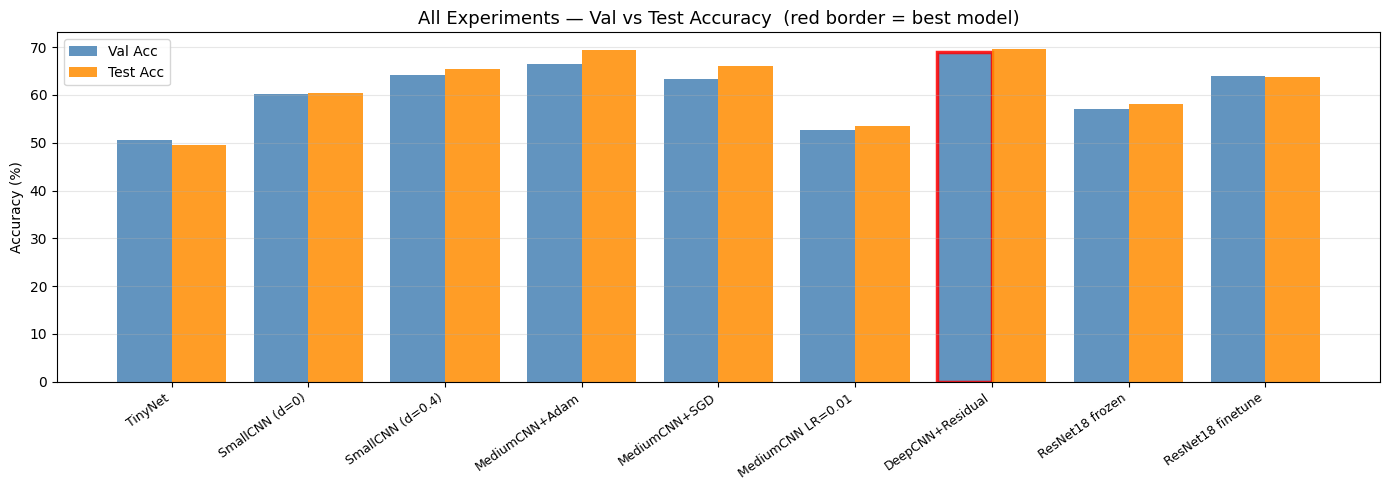

In [16]:
# ── FINAL RESULTS — all experiments complete ─────────────────────
val1,  test1  = 50.63, 49.60   # exp1  TinyNet           UNDERFITTING
val2,  test2  = 60.24, 60.32   # exp2  SmallCNN no reg   OVERFITTING
val3,  test3  = 64.17, 65.37   # exp3  SmallCNN dropout  BETTER FIT
val4,  test4  = 66.51, 69.41   # exp4  MediumCNN Adam    BALANCED
val5,  test5  = 63.39, 66.09   # exp5  MediumCNN SGD     OPTIMIZER COMPARE
val6, test6 = 52.66, 53.44   # exp6  MediumCNN LR=0.01  LR TOO HIGH
val7,  test7  = 68.99, 69.63   # exp7  DeepCNN Residual  BEST MODEL ✓
val8,  test8  = 57.15, 58.21   # exp8  ResNet18 frozen   TRANSFER LIMITED
val9,  test9  = 64.06, 63.81   # exp9  ResNet18 finetune TRANSFER FULL

results = [
    ("exp1_tinynet_baseline",    "TinyNet",           val1, test1, "Underfitting"),
    ("exp2_smallcnn_no_dropout", "SmallCNN (d=0)",    val2, test2, "Overfitting"),
    ("exp3_smallcnn_regularised","SmallCNN (d=0.4)",  val3, test3, "Better fit"),
    ("exp4_mediumcnn_adam",      "MediumCNN+Adam",    val4, test4, "Balanced"),
    ("exp5_mediumcnn_sgd",       "MediumCNN+SGD",     val5, test5, "Optimizer compare"),
    ("exp6_mediumcnn_highLR",    "MediumCNN LR=0.01", val6, test6, "LR ablation"),
    ("exp7_deepcnn_residual",    "DeepCNN+Residual",  val7, test7, "BEST MODEL"),
    ("exp8_resnet18_frozen",     "ResNet18 frozen",   val8, test8, "Transfer limited"),
    ("exp9_resnet18_finetune",   "ResNet18 finetune", val9, test9, "Transfer full"),
]

print(f"\n{'='*68}")
print(f"{'#':<4} {'Run':<28} {'Val':>8} {'Test':>8}  Diagnosis")
print("─"*68)
for i, (name, arch, v, t, diag) in enumerate(results, 1):
    marker = " ← BEST" if v == max(r[2] for r in results) else ""
    print(f"{i:<4} {name:<28} {v:>7.2f}% {t:>7.2f}%  {diag}{marker}")
print("="*68)

best = max(results, key=lambda r: r[2])
print(f"\nBest model : {best[0]}")
print(f"Best Val   : {best[2]:.2f}%")
print(f"Best Test  : {best[3]:.2f}%")

# Bar chart
fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(results))
bars_val  = ax.bar([i-0.2 for i in x], [r[2] for r in results], width=0.4, label="Val Acc",  color="steelblue",  alpha=0.85)
bars_test = ax.bar([i+0.2 for i in x], [r[3] for r in results], width=0.4, label="Test Acc", color="darkorange", alpha=0.85)

# Highlight best model
best_idx = [r[2] for r in results].index(max(r[2] for r in results))
bars_val[best_idx].set_edgecolor("red")
bars_val[best_idx].set_linewidth(2.5)

ax.set_xticks(list(x))
ax.set_xticklabels([r[1] for r in results], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_title("All Experiments — Val vs Test Accuracy  (red border = best model)", fontsize=13)
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")
/tmp/ipykernel_58/2137313278.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image  = Image.fromarray(pixels, mode="L")


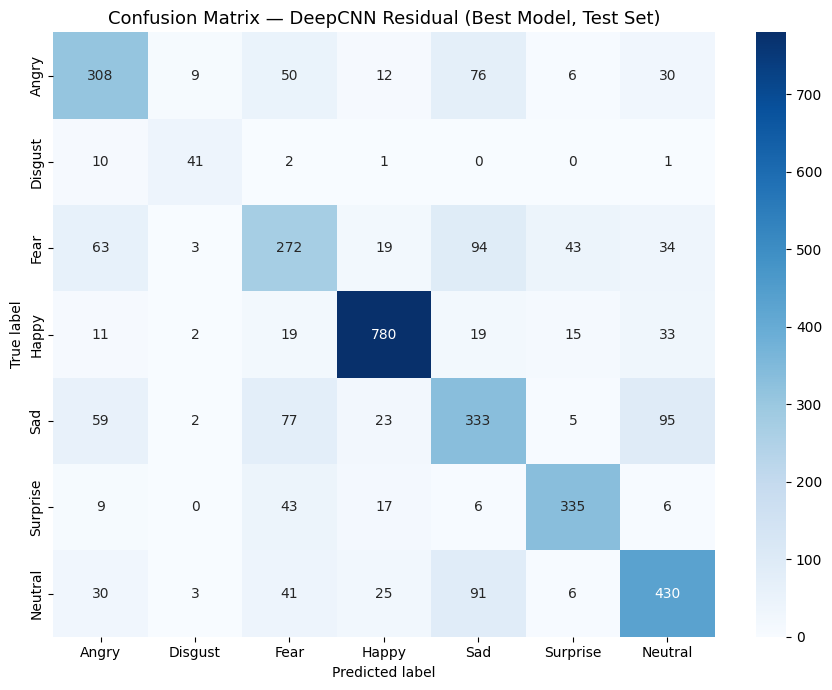


Per-class accuracy:
  Angry       308/491  = 62.7%
  Disgust      41/55   = 74.5%
  Fear        272/528  = 51.5%
  Happy       780/879  = 88.7%
  Sad         333/594  = 56.1%
  Surprise    335/416  = 80.5%
  Neutral     430/626  = 68.7%


In [18]:
# Load the best model — DeepCNN Residual (highest val accuracy: 68.99%)
best_model = DeepCNN(dropout=0.5).to(DEVICE)
best_model.load_state_dict(torch.load(
    str(SAVE_DIR / "best_exp7_deepcnn_residual.pth"), map_location=DEVICE
))
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in ts32:
        all_preds.extend(best_model(imgs.to(DEVICE)).argmax(1).cpu().tolist())
        all_labels.extend(lbls.tolist())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.title("Confusion Matrix — DeepCNN Residual (Best Model, Test Set)", fontsize=13)
plt.ylabel("True label"); plt.xlabel("Predicted label")
plt.tight_layout(); plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, emotion in enumerate(EMOTIONS):
    class_total = cm[i].sum()
    class_correct = cm[i][i]
    print(f"  {emotion:<10} {class_correct:>4}/{class_total:<4} = {100*class_correct/class_total:.1f}%")